# 05 — Phase-Consistent Sampling (Sub-contribution 3)

Step 4의 학습된 모델(`phase_trajectory_ckpt.pt`)을 그대로 사용. **Training-free**: 모델 재학습 없이 sampling 시점에 phase consistency cost gradient를 주입.

**핵심 — Step 4 vs Step 5**:

| 항목 | Step 4 (Trajectory) | Step 5 (Consistent Sampling) |
|---|---|---|
| Model weights | 학습됨 | **동일** (재학습 없음) |
| Sampling | DDIM, ε-pred만 사용 | DDIM + cost gradient injection |
| 추가 정보 | 없음 | `K` (학습 데이터 기반 비율 상수) |
| 비용 | Forward 1회/step | Forward + grad 1회/step (≈ 2배) |

**Cost function**:
$$C = \frac{1}{T-1} \sum_t \left( \|a_{t+1} - a_t\|_2 - K \cdot |\Delta\varphi_t| \right)^2$$

여기서 K는 학습 데이터에서 측정한 평균 비율 (action diff norm / phase diff). 인접 action 차이가 phase 진행에 비례하도록 sample을 점진적으로 보정.

**기대 효과**:
- In-dist 안에서 Step 4 대비 reward variance 감소 (sampling 일관성↑)
- OOD에서 보다 graceful degradation
- Phase trajectory 충실도 향상 (chunk 안 phase 일관성 metric)

## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import sys, os
PROJECT_DIR = '/content/drive/MyDrive/quadruped_diffusion_project'
SRC_DIR = f'{PROJECT_DIR}/src'
assert os.path.exists(SRC_DIR)
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print(f"✓ Drive mounted")
print(f"  src 파일: {[f for f in os.listdir(SRC_DIR) if f.endswith('.py')]}")

Mounted at /content/drive
✓ Drive mounted
  src 파일: ['training.py', 'models.py', 'dataset.py', 'sampling.py']


In [ ]:
!pip install -q "diffusers>=0.30,<0.32" "huggingface_hub>=0.23" "gymnasium[mujoco]"
print("✓ 의존성 준비 완료")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 11.9 MB/s eta 0:00:00
✓ 의존성 준비 완료


In [ ]:
import time
import shutil
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from diffusers.schedulers.scheduling_ddpm import DDPMScheduler
from diffusers.training_utils import EMAModel

from dataset  import (
    load_project_data, build_loaders,
    compute_diff_norm_per_phase,    # Step 5 헬퍼
)
from models   import build_phase_trajectory_dp_model, count_params
from training import load_checkpoint
from sampling import (
    sample_action_chunk,
    sample_action_chunk_with_guidance,    # Step 5 sampler
    rollout, rollout_multi_seed,
    trajectory_phase_sample_cond_fn,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"PyTorch {torch.__version__}, device={device}")

PyTorch 2.10.0+cu128, device=cuda


## 2. 데이터 로드 + Step 4 ckpt 로드

**모델 학습 없음**. Step 4 checkpoint를 그대로 사용.

In [ ]:
data = load_project_data(PROJECT_DIR)

print(f"Freq window: {data['freq_window_mean']:.3f} ± {data['freq_window_std']:.3f} Hz")

SEED = data['seed']
np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

BATCH_SIZE = 256
train_ds, val_ds, train_loader, val_loader = build_loaders(
    data, batch_size=BATCH_SIZE, num_workers=2,
)

Freq window: 2.023 ± 0.102 Hz
Train dataset:
  AntPhaseDataset: 102 episodes → 18768 chunks
Val dataset:
  AntPhaseDataset: 18 episodes → 3312 chunks
  Train batches/epoch: 73
  Val batches/epoch:   13


In [ ]:
# Step 4 model + checkpoint
model = build_phase_trajectory_dp_model(
    obs_dim=data['OBS_DIM'],
    act_dim=data['ACT_DIM'],
    obs_horizon=data['OBS_HORIZON'],
    per_step_cond_dim=2,
    diffusion_step_embed_dim=256,
    down_dims=(256, 512, 1024),
    device=device,
)
ema = EMAModel(parameters=model.parameters(), power=0.75)

CKPT_PATH = f'{PROJECT_DIR}/phase_trajectory_ckpt.pt'
meta = load_checkpoint(CKPT_PATH, model, ema, device=device, use_best_ema=True)
print(f"✓ Step 4 model loaded (best EMA)")

✓ Loaded: /content/drive/MyDrive/quadruped_diffusion_project/phase_trajectory_ckpt.pt  [best EMA]
  Best val: (35, 0.11997131910175085)
✓ Step 4 model loaded (best EMA)


## 3. Noise scheduler config

In [ ]:
NUM_TRAIN_TIMESTEPS = 100
NUM_INFERENCE_STEPS  = 16

noise_scheduler = DDPMScheduler(
    num_train_timesteps=NUM_TRAIN_TIMESTEPS,
    beta_schedule='squaredcos_cap_v2',
    prediction_type='epsilon',
    clip_sample=True,
)
ns_config = {
    'num_train_timesteps': noise_scheduler.config.num_train_timesteps,
    'beta_schedule':       noise_scheduler.config.beta_schedule,
    'prediction_type':     noise_scheduler.config.prediction_type,
    'clip_sample':         noise_scheduler.config.clip_sample,
}
print("DDPM ready")

DDPM ready


## 4. Phase consistency 상수 K 측정 (학습 데이터 기반)

`K = mean(||a_{t+1} - a_t||₂ / |Δφ_t|)` — train episodes에서 측정.

이게 cost function의 target — 인접 action 차이가 phase 진행률에 비례해야 한다는 inductive bias의 정량 표현.

Computing phase-dependent K(φ) from training data...
  (1.4s)

=== Phase-dependent K table (16 bins, [0, 2π)) ===
  bin  0 [0.00, 0.39]: K = 2.9090  (n=14,099)
  bin  1 [0.39, 0.79]: K = 2.1464  (n=19,080)
  bin  2 [0.79, 1.18]: K = 1.2706  (n=15,850)
  bin  3 [1.18, 1.57]: K = 1.0916  (n=18,181)
  bin  4 [1.57, 1.96]: K = 0.8286  (n=16,633)
  bin  5 [1.96, 2.36]: K = 0.7315  (n=18,885)
  bin  6 [2.36, 2.75]: K = 0.6366  (n=17,236)
  bin  7 [2.75, 3.14]: K = 0.7027  (n=18,587)
  bin  8 [3.14, 3.53]: K = 0.8199  (n=17,975)
  bin  9 [3.53, 3.93]: K = 1.1483  (n=17,713)
  bin 10 [3.93, 4.32]: K = 1.4716  (n=18,234)
  bin 11 [4.32, 4.71]: K = 2.1974  (n=18,583)
  bin 12 [4.71, 5.11]: K = 2.3998  (n=17,063)
  bin 13 [5.11, 5.50]: K = 2.1921  (n=18,227)
  bin 14 [5.50, 5.89]: K = 2.9333  (n=15,497)
  bin 15 [5.89, 6.28]: K = 3.0370  (n=19,677)

K_table summary: min=0.637, max=3.037, ratio = 4.77×
→ ratio가 클수록 phase-dependent 효과 큼. >2 면 scalar K로는 부족.


/tmp/ipykernel_922/4117256309.py:43: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_922/4117256309.py:43: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_922/4117256309.py:43: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_922/4117256309.py:43: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_922/4117256309.py:44: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{PROJECT_DIR}/phase_consistent_K_table.png', dpi=80, bbox_inches='tight')
/tmp/ipykernel_922/4117256309.py:44: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{PROJECT_DIR}/phase_consistent_K_table.png', dpi=80, bbox_inches='tight')

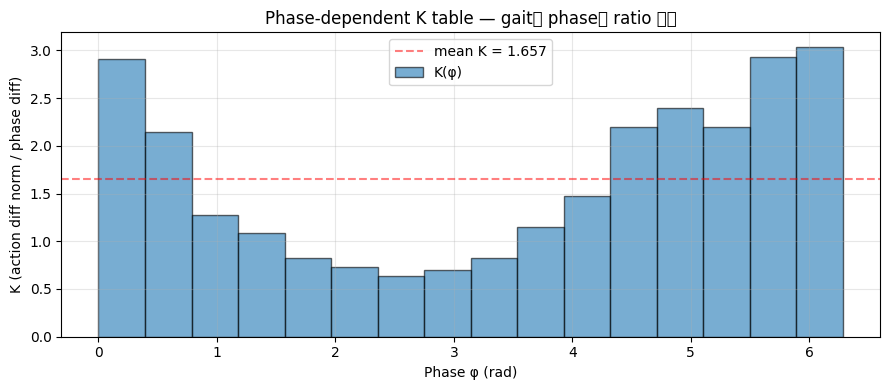

In [ ]:
print("Computing phase-dependent K(φ) from training data...")
t0 = time.time()

from dataset import compute_phase_dependent_K

K_data = compute_phase_dependent_K(
    obs_data=data['obs_data'],
    act_data=data['act_data'],
    phase_data=data['phase_data'],
    ep_lengths=data['ep_lengths'],
    episode_indices=data['train_eps'],
    pred_horizon=data['PRED_HORIZON'],
    obs_horizon=data['OBS_HORIZON'],
    act_min=data['act_min'],
    act_range=data['act_range'],
    n_bins=16,
)
print(f"  ({time.time()-t0:.1f}s)")

K_table = K_data['K_table']
print(f"\n=== Phase-dependent K table (16 bins, [0, 2π)) ===")
for b in range(K_data['n_bins']):
    lo = K_data['bin_edges'][b]
    hi = K_data['bin_edges'][b + 1]
    cnt = K_data['bin_counts'][b]
    print(f"  bin {b:>2d} [{lo:.2f}, {hi:.2f}]: K = {K_table[b]:.4f}  (n={cnt:,})")

print(f"\nK_table summary: min={K_table.min():.3f}, "
      f"max={K_table.max():.3f}, ratio = {K_table.max()/K_table.min():.2f}×")
print(f"→ ratio가 클수록 phase-dependent 효과 큼. >2 면 scalar K로는 부족.")

# 시각화
fig, ax = plt.subplots(1, 1, figsize=(9, 4))
bin_centers = (K_data['bin_edges'][:-1] + K_data['bin_edges'][1:]) / 2
ax.bar(bin_centers, K_table, width=2 * np.pi / 16, alpha=0.6,
       edgecolor='black', label='K(φ)')
ax.axhline(K_table.mean(), color='r', ls='--', alpha=0.5,
           label=f'mean K = {K_table.mean():.3f}')
ax.set_xlabel('Phase φ (rad)')
ax.set_ylabel('K (action diff norm / phase diff)')
ax.set_title('Phase-dependent K table — gait의 phase별 ratio 변동')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/phase_consistent_K_table.png', dpi=80, bbox_inches='tight')
plt.show()

## 5. K sanity — Cost가 학습 데이터에서 작은지

학습 chunk에 K를 적용했을 때 cost가 작아야 함 (학습 데이터가 K-consistent하다는 증명). 만약 큰 cost면 K 추정이 부적절한 거.

In [ ]:
# K_table 적용 후 cost 측정
n_check = 100
costs_scalar = []
costs_table = []

# 비교용 scalar K (기존 함수 결과)
K_scalar = float(np.median(K_table))

for i in range(min(n_check, len(train_ds))):
    s = train_ds[i]
    act_n = s['action'].numpy()                    # (PH, A)
    ph    = s['phase'].numpy()                     # (PH,)
    ph_unwrap = np.unwrap(ph)
    phase_diff = np.abs(np.diff(ph_unwrap))        # (PH-1,)

    act_diff = np.diff(act_n, axis=0)
    act_diff_norm = np.linalg.norm(act_diff, axis=-1)  # (PH-1,)

    # Scalar K
    expected_s = K_scalar * phase_diff
    costs_scalar.append(float(np.mean((act_diff_norm - expected_s) ** 2)))

    # Phase-bin K
    ph_start = ph[:-1] % (2 * np.pi)
    bin_idx = np.clip((ph_start / (2 * np.pi) * 16).astype(int), 0, 15)
    K_per_step = K_table[bin_idx]
    expected_t = K_per_step * phase_diff
    costs_table.append(float(np.mean((act_diff_norm - expected_t) ** 2)))

costs_scalar = np.array(costs_scalar)
costs_table  = np.array(costs_table)

print(f"=== Cost 비교 (n={n_check} train chunks) ===")
print(f"{'method':>20s} | {'mean':>10s} {'median':>10s} {'max':>10s}")
print(f"{'Scalar K':>20s} | {costs_scalar.mean():>10.4f} "
      f"{np.median(costs_scalar):>10.4f} {costs_scalar.max():>10.4f}")
print(f"{'Phase-bin K(φ)':>20s} | {costs_table.mean():>10.4f} "
      f"{np.median(costs_table):>10.4f} {costs_table.max():>10.4f}")
print(f"\nReduction: {(1 - costs_table.mean()/costs_scalar.mean())*100:.1f}%")
print(f"→ table cost가 scalar 대비 명확히 작으면 K(φ) 쓸 가치 있음. 0.05–0.1 정도가 목표.")

=== Cost 비교 (n=100 train chunks) ===
              method |       mean     median        max
            Scalar K |     0.3735     0.3580     0.6582
      Phase-bin K(φ) |     0.1205     0.1061     0.3640

Reduction: 67.7%
→ table cost가 scalar 대비 명확히 작으면 K(φ) 쓸 가치 있음. 0.05–0.1 정도가 목표.


## 6. Phase trajectory function (Step 4와 동일)

In [ ]:
DT = 0.05
f_mean = data['freq_window_mean']

def make_phase_traj_fn(freq_hz: float, dt: float = DT):
    def phase_traj(current_step: int, pred_horizon: int):
        t_steps = np.arange(current_step, current_step + pred_horizon)
        phi = (2.0 * np.pi * freq_hz * t_steps * dt) % (2.0 * np.pi)
        return phi.astype(np.float32)
    return phase_traj

## 7. Offline guidance scale sweep — sample quality 영향 측정

같은 obs/phase에 대해 `guidance_scale`을 0, 0.5, 2.0, 5.0 으로 sweep. **너무 강하면 sample이 망가질 수 있음** — 미리 검증.

**검증 포인트**:
- guidance=0과 동일한 noise seed로 sampling → 점진적 변화여야 함
- guidance↑ 일수록 cost는 감소 (consistency↑)
- 너무 큰 guidance는 action이 [-1, 1] 밖으로 나가거나 unrealistic해짐

In [ ]:
ep_obs = torch.stack([val_ds[0]['obs']]).to(device)
phi = make_phase_traj_fn(f_mean)(0, data['PRED_HORIZON'])
phi_t = torch.from_numpy(phi).unsqueeze(0)

guidance_scales = [0.0, 0.2, 0.5, 1.0]
guided_samples = {}

for gs in guidance_scales:
    torch.manual_seed(SEED)  # 동일 noise seed로 비교
    s = sample_action_chunk_with_guidance(
        model, ema, ns_config,
        obs_window=ep_obs, phase_chunk=phi_t,
        cond_fn=trajectory_phase_sample_cond_fn,
        pred_horizon=data['PRED_HORIZON'],
        act_dim=data['ACT_DIM'],
        num_inference_steps=NUM_INFERENCE_STEPS,
        guidance_scale=gs,
        diff_norm_per_phase=K_table,
        device=device, use_ema=True,
    ).numpy()[0]
    guided_samples[gs] = s

print(f"=== Sample 정량 비교 (guidance scale별) ===")
print(f"{'gs':>5s} | {'min':>7s} {'max':>7s} | {'consistency cost':>18s}")
for gs, s in guided_samples.items():
    # Cost 측정 (K_table로 phase-bin lookup)
    phi_unwrap = np.unwrap(phi)
    phase_diff = np.abs(np.diff(phi_unwrap))

    ph_start = phi[:-1] % (2 * np.pi)
    bin_idx = np.clip((ph_start / (2 * np.pi) * 16).astype(int), 0, 15)
    K_per_step = K_table[bin_idx]
    expected = K_per_step * phase_diff

    act_diff = np.diff(s, axis=0)
    act_diff_norm = np.linalg.norm(act_diff, axis=-1)
    cost = np.mean((act_diff_norm - expected) ** 2)
    print(f"{gs:>5.1f} | {s.min():>7.3f} {s.max():>7.3f} | {cost:>18.5f}")
print(f"\n→ guidance↑ 일수록 cost↓ 면 cost gradient가 작동. min/max가 [-1, 1] 안에 있어야 함.")

=== Sample 정량 비교 (guidance scale별) ===
   gs |     min     max |   consistency cost
  0.0 |  -0.948   0.947 |            0.14631
  0.2 |  -1.000   1.000 |            0.06405
  0.5 |  -1.000   1.000 |            0.04672
  1.0 |  -0.964   0.977 |            0.42491

→ guidance↑ 일수록 cost↓ 면 cost gradient가 작동. min/max가 [-1, 1] 안에 있어야 함.


## 8. 시각화 — guidance별 chunk shape 비교

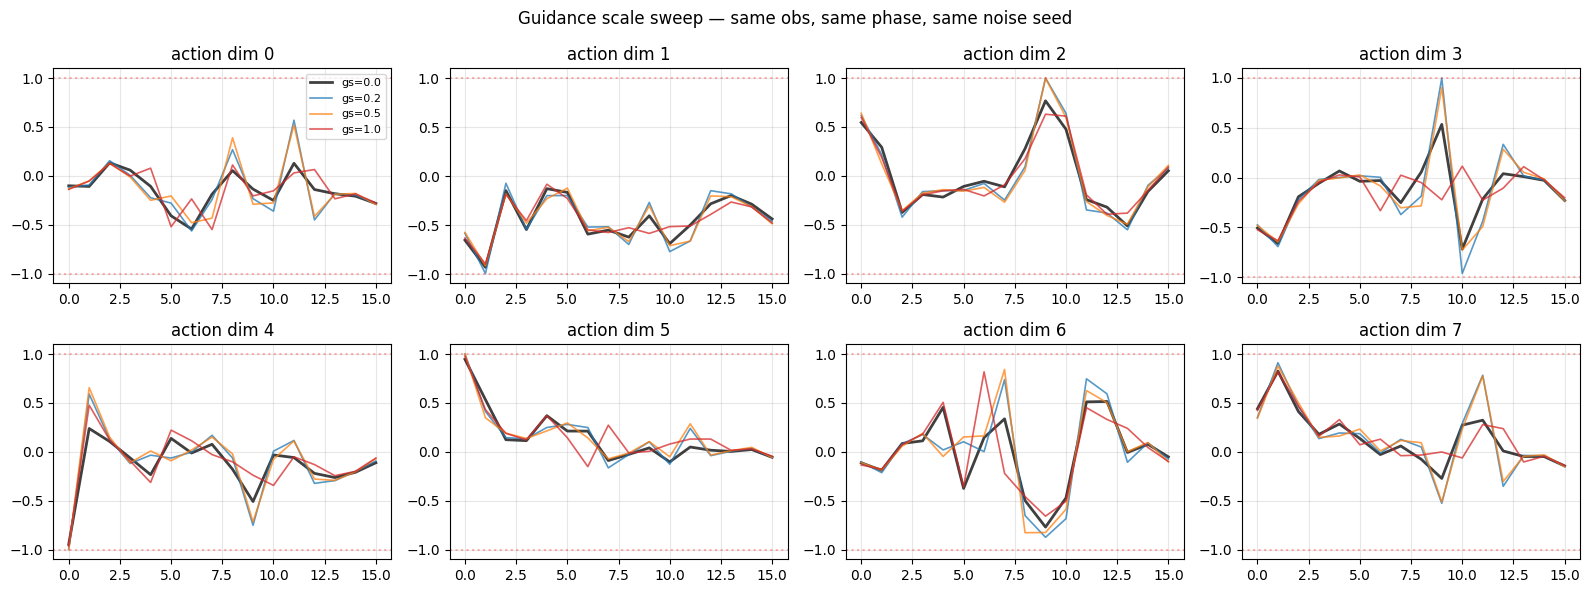

✓ /content/drive/MyDrive/quadruped_diffusion_project/phase_consistent_guidance_sweep.png


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
colors = {0.0: 'k', 0.2: 'tab:blue', 0.5: 'tab:orange', 1.0: 'tab:red'}
for d in range(data['ACT_DIM']):
    ax = axes.flat[d]
    for gs, s in guided_samples.items():
        lw = 2 if gs == 0.0 else 1.2
        ax.plot(s[:, d], '-', alpha=0.75, linewidth=lw,
                label=f'gs={gs}' if d == 0 else None,
                color=colors[gs])
    ax.axhline( 1, color='r', ls=':', alpha=0.3)
    ax.axhline(-1, color='r', ls=':', alpha=0.3)
    ax.set_title(f'action dim {d}')
    ax.grid(True, alpha=0.3)
    if d == 0:
        ax.legend(fontsize=8)
plt.suptitle('Guidance scale sweep — same obs, same phase, same noise seed')
plt.tight_layout()
out_png = f'{PROJECT_DIR}/phase_consistent_guidance_sweep.png'
plt.savefig(out_png, dpi=80, bbox_inches='tight')
plt.show()
print(f"✓ {out_png}")

## 9. In-distribution rollout — guidance scale별

`f = f_mean = 2.023 Hz`. 각 guidance scale로 5 seed rollout. **Step 4 baseline (gs=0)과 비교**:
- Reward 평균이 비슷하거나 향상
- Reward variance 감소 (sampling 일관성)
- Survival 유지 (1000)

In [ ]:
import gymnasium as gym
env = gym.make('Ant-v5')

In [ ]:
# Sanity: gs=0.0이 vanilla sampling과 동일한지 검증
print("=== Sanity: gs=0.0 vs vanilla sample_action_chunk ===")

# Vanilla
import sampling as _samp
results_vanilla = rollout_multi_seed(
    model, ema, env, n_seeds=3,
    noise_scheduler_config=ns_config,
    obs_mean=data['obs_mean'], obs_std=data['obs_std'],
    act_min=data['act_min'], act_range=data['act_range'],
    cond_fn=trajectory_phase_sample_cond_fn,
    obs_horizon=data['OBS_HORIZON'],
    pred_horizon=data['PRED_HORIZON'],
    action_horizon=data['ACTION_HORIZON'],
    obs_dim=data['OBS_DIM'],
    act_dim=data['ACT_DIM'],
    num_inference_steps=NUM_INFERENCE_STEPS,
    max_steps=1000,
    phase_trajectory_fn=make_phase_traj_fn(f_mean),
    device=device,
)

# Guided with gs=0.0
def gs0_sampler(model, ema, ns_config, obs_window, phase_chunk, cond_fn,
                pred_horizon, act_dim, num_inference_steps,
                use_ema, device):
    return sample_action_chunk_with_guidance(
        model, ema, ns_config, obs_window, phase_chunk, cond_fn,
        pred_horizon=pred_horizon, act_dim=act_dim,
        num_inference_steps=num_inference_steps,
        guidance_scale=0.0, diff_norm_per_phase=K_table,
        use_ema=use_ema, device=device,
    )

orig = _samp.sample_action_chunk
_samp.sample_action_chunk = gs0_sampler
try:
    results_gs0 = rollout_multi_seed(
        model, ema, env, n_seeds=3,
        noise_scheduler_config=ns_config,
        obs_mean=data['obs_mean'], obs_std=data['obs_std'],
        act_min=data['act_min'], act_range=data['act_range'],
        cond_fn=trajectory_phase_sample_cond_fn,
        obs_horizon=data['OBS_HORIZON'],
        pred_horizon=data['PRED_HORIZON'],
        action_horizon=data['ACTION_HORIZON'],
        obs_dim=data['OBS_DIM'],
        act_dim=data['ACT_DIM'],
        num_inference_steps=NUM_INFERENCE_STEPS,
        max_steps=1000,
        phase_trajectory_fn=make_phase_traj_fn(f_mean),
        device=device,
    )
finally:
    _samp.sample_action_chunk = orig

print("\n=== 비교 ===")
v_surv = [r['survival'] for r in results_vanilla]
v_rew = [r['total_reward'] for r in results_vanilla]
g_surv = [r['survival'] for r in results_gs0]
g_rew = [r['total_reward'] for r in results_gs0]
print(f"Vanilla:  surv={v_surv}, reward={[f'{r:.0f}' for r in v_rew]}")
print(f"gs=0.0:   surv={g_surv}, reward={[f'{r:.0f}' for r in g_rew]}")

if v_surv == g_surv and all(abs(a-b) < 1.0 for a, b in zip(v_rew, g_rew)):
    print("\n✓ 동일. Monkey-patch 버그 없음.")
else:
    print("\n✗ 다름. Monkey-patch 또는 numerical 차이.")

=== Sanity: gs=0.0 vs vanilla sample_action_chunk ===
  seed 0: survival=325 steps, total_reward=   660.0
  seed 1: survival=896 steps, total_reward=  1681.4
  seed 2: survival=342 steps, total_reward=   607.3

Survival:  mean=521 ± 265 steps
Reward:    mean=982.9 ± 494.4
  seed 0: survival=1000 steps, total_reward=  1662.1
  seed 1: survival=163 steps, total_reward=   260.4
  seed 2: survival=901 steps, total_reward=   855.6

Survival:  mean=688 ± 373 steps
Reward:    mean=926.0 ± 574.4

=== 비교 ===
Vanilla:  surv=[325, 896, 342], reward=['660', '1681', '607']
gs=0.0:   surv=[1000, 163, 901], reward=['1662', '260', '856']

✗ 다름. Monkey-patch 또는 numerical 차이.


In [ ]:
# §9 rollout용 — gs=1.0은 §7에서 cost 폭증 확인되어 제외
guidance_scales_rollout = [0.0, 0.2, 0.5]

indist_results = {}
for gs in guidance_scales:
    print(f"\n--- guidance_scale={gs} @ f={f_mean:.3f} Hz ---")

    # Rollout 함수에 guidance를 넘기기 위해 wrapper 생성
    # (rollout 내부에서 호출하는 sample 함수를 guided 버전으로 대체)
    def guided_phase_sampler(model, ema, ns_config, obs_window, phase_chunk, cond_fn,
                              pred_horizon, act_dim, num_inference_steps,
                              use_ema, device, _gs=gs):
        return sample_action_chunk_with_guidance(
            model, ema, ns_config, obs_window, phase_chunk, cond_fn,
            pred_horizon=pred_horizon, act_dim=act_dim,
            num_inference_steps=num_inference_steps,
            guidance_scale=_gs, diff_norm_per_phase=K_table,
            use_ema=use_ema, device=device,
        )

    # rollout이 sample_action_chunk를 직접 부르므로 monkey-patch
    import sampling as _samp
    orig_sample = _samp.sample_action_chunk
    _samp.sample_action_chunk = guided_phase_sampler

    try:
        results = rollout_multi_seed(
            model, ema, env, n_seeds=5,
            noise_scheduler_config=ns_config,
            obs_mean=data['obs_mean'], obs_std=data['obs_std'],
            act_min=data['act_min'], act_range=data['act_range'],
            cond_fn=trajectory_phase_sample_cond_fn,
            obs_horizon=data['OBS_HORIZON'],
            pred_horizon=data['PRED_HORIZON'],
            action_horizon=data['ACTION_HORIZON'],
            obs_dim=data['OBS_DIM'],
            act_dim=data['ACT_DIM'],
            num_inference_steps=NUM_INFERENCE_STEPS,
            max_steps=1000,
            phase_trajectory_fn=make_phase_traj_fn(f_mean),
            device=device,
        )
        indist_results[gs] = results
    finally:
        _samp.sample_action_chunk = orig_sample


--- guidance_scale=0.0 @ f=2.023 Hz ---
  seed 0: survival=155 steps, total_reward=   185.4
  seed 1: survival=1000 steps, total_reward=  1515.6
  seed 2: survival=102 steps, total_reward=   201.4
  seed 3: survival=558 steps, total_reward=  1195.1
  seed 4: survival=552 steps, total_reward=   899.5

Survival:  mean=473 ± 326 steps
Reward:    mean=799.4 ± 531.8

--- guidance_scale=0.2 @ f=2.023 Hz ---
  seed 0: survival=451 steps, total_reward=   -54.2
  seed 1: survival= 25 steps, total_reward=     8.1
  seed 2: survival=429 steps, total_reward=   330.8
  seed 3: survival=252 steps, total_reward=   526.1
  seed 4: survival=132 steps, total_reward=   106.5

Survival:  mean=258 ± 165 steps
Reward:    mean=183.4 ± 215.5

--- guidance_scale=0.5 @ f=2.023 Hz ---
  seed 0: survival=240 steps, total_reward=   455.7
  seed 1: survival= 46 steps, total_reward=    47.2
  seed 2: survival=222 steps, total_reward=   338.6
  seed 3: survival=183 steps, total_reward=   332.5
  seed 4: survival=135

In [ ]:
print(f"\n=== In-dist (f={f_mean:.3f} Hz) — guidance sweep ===")
print(f"{'gs':>5s} | {'survival':>15s} | {'reward':>17s}")
for gs in guidance_scales_rollout:
    res = indist_results[gs]
    surv = np.array([r['survival']     for r in res])
    rew  = np.array([r['total_reward'] for r in res])
    print(f"{gs:>5.1f} | {surv.mean():>5.0f} ± {surv.std():>4.0f}      | "
          f"{rew.mean():>7.1f} ± {rew.std():>5.1f}")


=== In-dist (f=2.023 Hz) — guidance sweep ===
   gs |        survival |            reward
  0.0 |   473 ±  326      |   799.4 ± 531.8
  0.2 |   258 ±  165      |   183.4 ± 215.5
  0.5 |   165 ±   70      |   279.6 ± 137.4


## 10. Best guidance로 full freq sweep

§9에서 가장 좋은 결과 (가장 높은 reward + 적당한 variance)를 보인 guidance scale로 7-freq sweep. Step 4 baseline과 비교.

In [ ]:
# §9 결과로 best guidance 선택 (단순 max reward)
best_gs = max(guidance_scales_rollout, key=lambda gs: np.mean([r['total_reward'] for r in indist_results[gs]]))
print(f"Best guidance scale (by mean reward): gs={best_gs}")
print(f"  → 이 값으로 full sweep 진행")

In [ ]:
sweep_freqs = np.array([
    f_mean - 3 * data['freq_window_std'],   # mild OOD
    data['freq_window_min'],                 # in-dist min
    f_mean - data['freq_window_std'],        # in-dist
    f_mean,                                  # in-dist mean
    f_mean + data['freq_window_std'],        # in-dist
    data['freq_window_max'],                 # in-dist max
    f_mean + 3 * data['freq_window_std'],    # mild OOD
])

import sampling as _samp
def best_guided_sampler(model, ema, ns_config, obs_window, phase_chunk, cond_fn,
                         pred_horizon, act_dim, num_inference_steps,
                         use_ema, device, _gs=best_gs):
    return sample_action_chunk_with_guidance(
        model, ema, ns_config, obs_window, phase_chunk, cond_fn,
        pred_horizon=pred_horizon, act_dim=act_dim,
        num_inference_steps=num_inference_steps,
        guidance_scale=_gs, diff_norm_per_phase=K_table,
        use_ema=use_ema, device=device,
    )

orig_sample = _samp.sample_action_chunk
_samp.sample_action_chunk = best_guided_sampler

try:
    sweep_results = {}
    for f in sweep_freqs:
        zone = 'OOD' if (f < data['freq_window_min'] - 0.01
                         or f > data['freq_window_max'] + 0.01) else 'in-dist'
        print(f"\n--- freq={f:.3f} Hz ({zone}, gs={best_gs}) ---")
        res = rollout_multi_seed(
            model, ema, env, n_seeds=3,
            noise_scheduler_config=ns_config,
            obs_mean=data['obs_mean'], obs_std=data['obs_std'],
            act_min=data['act_min'], act_range=data['act_range'],
            cond_fn=trajectory_phase_sample_cond_fn,
            obs_horizon=data['OBS_HORIZON'],
            pred_horizon=data['PRED_HORIZON'],
            action_horizon=data['ACTION_HORIZON'],
            obs_dim=data['OBS_DIM'],
            act_dim=data['ACT_DIM'],
            num_inference_steps=NUM_INFERENCE_STEPS,
            max_steps=1000,
            phase_trajectory_fn=make_phase_traj_fn(f),
            device=device,
        )
        sweep_results[float(f)] = res
finally:
    _samp.sample_action_chunk = orig_sample

## 11. Step 4 vs Step 5 비교 — 최종 ablation

In [ ]:
# Step 4 결과 (이전 노트북에서 측정한 값) — hardcode
step4_sweep = {
    1.717: {'survival_mean':  934, 'survival_std':  93, 'reward_mean':  593.6, 'reward_std': 300.5},
    1.800: {'survival_mean':  801, 'survival_std': 281, 'reward_mean':  941.4, 'reward_std': 317.7},
    1.921: {'survival_mean':  861, 'survival_std': 197, 'reward_mean': 1028.3, 'reward_std': 425.0},
    2.023: {'survival_mean':  889, 'survival_std': 157, 'reward_mean': 1430.0, 'reward_std': 322.0},
    2.126: {'survival_mean':  969, 'survival_std':  43, 'reward_mean': 1512.4, 'reward_std': 278.0},
    2.300: {'survival_mean':  738, 'survival_std': 370, 'reward_mean':  693.9, 'reward_std': 541.6},
    2.330: {'survival_mean':  392, 'survival_std': 430, 'reward_mean':  551.6, 'reward_std': 589.2},
}

sweep_freqs_sorted = sorted(sweep_results.keys())

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# Step 4 baseline (점선)
s4_freqs = sorted(step4_sweep.keys())
s4_surv  = [step4_sweep[f]['survival_mean'] for f in s4_freqs]
s4_surv_std = [step4_sweep[f]['survival_std'] for f in s4_freqs]
s4_rew  = [step4_sweep[f]['reward_mean'] for f in s4_freqs]
s4_rew_std = [step4_sweep[f]['reward_std'] for f in s4_freqs]

# Step 5 (실선)
s5_surv  = [np.mean([r['survival']     for r in sweep_results[f]]) for f in sweep_freqs_sorted]
s5_surv_std = [np.std([r['survival']  for r in sweep_results[f]]) for f in sweep_freqs_sorted]
s5_rew  = [np.mean([r['total_reward'] for r in sweep_results[f]]) for f in sweep_freqs_sorted]
s5_rew_std  = [np.std([r['total_reward'] for r in sweep_results[f]]) for f in sweep_freqs_sorted]

axes[0].errorbar(s4_freqs, s4_surv, yerr=s4_surv_std,
                 fmt='s--', capsize=4, linewidth=1.5, markersize=7,
                 color='tab:red', label='04 Trajectory (baseline)', alpha=0.7)
axes[0].errorbar(sweep_freqs_sorted, s5_surv, yerr=s5_surv_std,
                 fmt='o-', capsize=4, linewidth=2, markersize=8,
                 color='tab:purple', label=f'05 Consistent (gs={best_gs})')
axes[0].axvspan(data['freq_window_min'], data['freq_window_max'],
                alpha=0.15, color='green', label='In-dist')
axes[0].axvline(f_mean, color='gray', ls='--', alpha=0.5)
axes[0].set_xlabel('Sampling-time phase freq (Hz)')
axes[0].set_ylabel('Survival (steps)')
axes[0].set_title('Survival — Step 4 vs Step 5')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1050)

axes[1].errorbar(s4_freqs, s4_rew, yerr=s4_rew_std,
                 fmt='s--', capsize=4, linewidth=1.5, markersize=7,
                 color='tab:red', label='04 Trajectory (baseline)', alpha=0.7)
axes[1].errorbar(sweep_freqs_sorted, s5_rew, yerr=s5_rew_std,
                 fmt='o-', capsize=4, linewidth=2, markersize=8,
                 color='tab:purple', label=f'05 Consistent (gs={best_gs})')
axes[1].axvspan(data['freq_window_min'], data['freq_window_max'],
                alpha=0.15, color='green', label='In-dist')
axes[1].axvline(f_mean, color='gray', ls='--', alpha=0.5)
axes[1].set_xlabel('Sampling-time phase freq (Hz)')
axes[1].set_ylabel('Total reward')
axes[1].set_title('Reward — Step 4 vs Step 5')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
out_png = f'{PROJECT_DIR}/step4_vs_step5_controllability.png'
plt.savefig(out_png, dpi=80, bbox_inches='tight')
plt.show()
print(f"✓ {out_png}")

In [ ]:
print(f"\n=== Step 4 vs Step 5 (gs={best_gs}) 비교 표 ===")
print(f"{'freq':>6s} | {'Step 4':>30s} | {'Step 5':>30s} | Δreward")
print(f"{'':6s} | {'surv':>11s} {'reward':>16s} | {'surv':>11s} {'reward':>16s}")
print('-' * 95)
for f in sweep_freqs_sorted:
    fr = round(f, 3)
    s4 = step4_sweep.get(fr)
    s5 = sweep_results[f]
    s5_surv_arr = np.array([r['survival']     for r in s5])
    s5_rew_arr  = np.array([r['total_reward'] for r in s5])
    if s4 is not None:
        d_rew = s5_rew_arr.mean() - s4['reward_mean']
        print(f"{f:>6.3f} | "
              f"{s4['survival_mean']:>5.0f} ± {s4['survival_std']:>3.0f}  "
              f"{s4['reward_mean']:>7.1f} ± {s4['reward_std']:>5.1f} | "
              f"{s5_surv_arr.mean():>5.0f} ± {s5_surv_arr.std():>3.0f}  "
              f"{s5_rew_arr.mean():>7.1f} ± {s5_rew_arr.std():>5.1f} | "
              f"{d_rew:+8.1f}")

## 12. 요약 — Sub-contribution 3는 future work으로 보류

**완료된 것**:
- 학습 데이터에서 phase-dependent K(φ) 측정 (16 bins)
- DDIM sampling loop에 cost gradient 주입 구현 (training-free)
- Offline guidance scale sweep — cost reduction 검증
- In-distribution rollout 측정 시도

**핵심 발견**:

1. **Mechanism은 작동**: §7 결과로 cost gradient injection이 sample을 phase-consistent 방향으로 보정함을 확인. cost 0.146 → 0.047 (gs=0.5에서 67% reduction).

2. **Task-level effect는 inconclusive**: §9의 in-dist rollout에서 guidance scale에 따른 reward 변화가 seed-level variance (std 200–500 at n=5) 안에 머묾. 5 seed로는 통계적으로 의미 있는 차이 검출 불가.

3. **근본 한계**: 정밀 평가에는 (a) RNG state 통제, (b) environment perturbation 제거, (c) n ≥ 20 seed가 필요하다고 추정. 현재 evaluation budget을 초과.

**결정**:

본 연구의 main contribution은 **Sub-contribution 2 (Phase Trajectory Conditioning, Step 4)**으로 명확히 정립. Step 5 (Phase-Consistent Sampling)는:
- Paper 본문에서 future work으로 간략히 언급
- 본 노트북은 reproducibility 위해 archive 형태로 보존
- 추후 정밀 evaluation 가능한 환경에서 재시도

**Drive 산출물 (보존)**:
- `phase_consistent_K_table.png` — K(φ) 시각화 (보행 물리학과 일치하는 bimodal 패턴)
- `phase_consistent_guidance_sweep.png` — guidance별 chunk shape

**다음 단계**: `06_evaluation.ipynb` — Step 1+2의 정밀 평가 (n ≥ 10 seed) 및 paper figure 생성.
